# Predictions for Air Pollution


In this example, we will download CAMS air pollution data for 11 June 2022 at 0.4 degrees resolution and run Aurora Air Pollution on this data.


Running this notebook requires additional Python packages. You can install these as follows:

    pip install cdsapi matplotlib


## Downloading the Data


To begin with, register an account with the Atmosphere Data Store and create `$HOME/.cdsapirc` with the following content:

    url: https://ads.atmosphere.copernicus.eu/api
    key: <API key>

You can find your API key on your account page.

In order to be able to download CAMS data, you need to accept the terms of use on the dataset page.

Warning
The URL in `$HOME/.cdsapirc` is `https://ads.atmosphere.copernicus.eu/api`, which conflicts with the URL `https://cds.climate.copernicus.eu/api` needed to download e.g. ERA5 data. You will need to manually switch between the URLs.


We now download the CAMS data.


In [1]:
# ---- Configuration (edit these) ----
from datetime import datetime, timedelta, timezone
from pathlib import Path

INIT_DATE = "2026-04-01"          # YYYY-MM-DD (UTC)
INIT_HOUR_UTC = 0                  # 0 or 12 (UTC). 12 matches the example.
PREDICTION_WINDOW_DAYS = 2         # Run Aurora this many days.
AURORA_STEP_HOURS = 12              # Aurora air-pollution example advances 12h per step.

DO_DOWNLOAD_CAMS_INIT = True        # Download just what is needed to build the initial Batch.
DO_DOWNLOAD_CAMS_RANGE = False      # Download CAMS analysis (leadtime 0) across the whole window.
DO_DOWNLOAD_CAMS_FORECAST = True   # Download a single CAMS forecast run from INIT_* for comparison.

CAMS_LEADTIME_STEP_HOURS = 12       # Used when DO_DOWNLOAD_CAMS_FORECAST=True.
CAMS_FORECAST_MAX_HOURS = 120       # Cap leadtime to match dataset horizon limits.

DOWNLOAD_DIR = "/mnt/data3/cams"
OVERWRITE_DOWNLOADS = False
STATIC_VARS_PICKLE_PATH = ""      # Optional local static pickle path. Empty uses env/default fallback.
DEFAULT_STATIC_FNAME = "aurora-0.4-air-pollution-static.pickle"  # Static variables including land-sea mask, elevation, soil type, and emissions
LEGACY_STATIC_FNAMES = ["aurora-0.4-air-pollution.pickle"]
RUN_AURORA = True
run_on_foundry = False              # Default local execution. Set True to use Foundry.

SAVE_PREDICTIONS_NETCDF = True
OVERWRITE_PREDICTIONS_NETCDF = False

INIT_DATETIME_UTC = datetime.strptime(
    f"{INIT_DATE} {INIT_HOUR_UTC:02d}:00", "%Y-%m-%d %H:%M"
).replace(tzinfo=timezone.utc)
BATCH_HISTORY_DATETIMES_UTC = [
    INIT_DATETIME_UTC - timedelta(hours=AURORA_STEP_HOURS),
    INIT_DATETIME_UTC,
]
PREDICTION_END_DATETIME_UTC = INIT_DATETIME_UTC + timedelta(days=PREDICTION_WINDOW_DAYS)

# Derive the predictions filename from the actual init/window so the
# output never lags the date variables above.
PREDICTIONS_OUTPUT_FILENAME = (
    f"aurora-cams-predictions_{INIT_DATETIME_UTC.strftime('%Y-%m-%d')}"
    f"_{PREDICTION_END_DATETIME_UTC.strftime('%Y-%m-%d')}.nc"
)
PREDICTIONS_OUTPUT_FILE = f"{DOWNLOAD_DIR}/{PREDICTIONS_OUTPUT_FILENAME}"

if AURORA_STEP_HOURS <= 0:
    raise ValueError("AURORA_STEP_HOURS must be positive.")
if (PREDICTION_WINDOW_DAYS * 24) % AURORA_STEP_HOURS != 0:
    raise ValueError(
        "PREDICTION_WINDOW_DAYS * 24 must be divisible by AURORA_STEP_HOURS to get whole rollout steps."
    )
AURORA_NUM_STEPS = int((PREDICTION_WINDOW_DAYS * 24) / AURORA_STEP_HOURS)

if CAMS_LEADTIME_STEP_HOURS <= 0:
    raise ValueError("CAMS_LEADTIME_STEP_HOURS must be positive.")
if CAMS_FORECAST_MAX_HOURS < 0:
    raise ValueError("CAMS_FORECAST_MAX_HOURS cannot be negative.")

download_path = Path(DOWNLOAD_DIR).expanduser()
download_path.mkdir(parents=True, exist_ok=True)

run_stamp = f"{INIT_DATETIME_UTC:%Y-%m-%dT%H}Z"
init_zip_path = download_path / f"{run_stamp}-cams-init.nc.zip"
init_surface_path = download_path / f"{run_stamp}-cams-init-surface-level.nc"
init_atmos_path = download_path / f"{run_stamp}-cams-init-atmospheric.nc"
range_zip_path = download_path / f"{run_stamp}-cams-range-lead0.nc.zip"
forecast_zip_path = download_path / f"{run_stamp}-cams-forecast.nc.zip"
forecast_base_name = forecast_zip_path.name.removesuffix(".zip").removesuffix(".nc")
forecast_surface_path = download_path / f"{forecast_base_name}-surface-level.nc"
forecast_atmos_path = download_path / f"{forecast_base_name}-atmospheric.nc"
predictions_output_path = Path(PREDICTIONS_OUTPUT_FILE).expanduser()

print(f"Initial datetime (UTC): {INIT_DATETIME_UTC.isoformat()}")
print(f"Prediction window: {PREDICTION_WINDOW_DAYS} day(s) -> {AURORA_NUM_STEPS} Aurora step(s)")
print(f"Download directory: {download_path}")
print(f"Predictions NetCDF: {predictions_output_path}")
print(f"Forecast surface NetCDF: {forecast_surface_path}")


Initial datetime (UTC): 2026-04-01T00:00:00+00:00
Prediction window: 2 day(s) -> 4 Aurora step(s)
Download directory: /mnt/data2/cams
Predictions NetCDF: /mnt/data2/cams/aurora-cams-predictions_2026-02-01_2026-02-06.nc
Forecast surface NetCDF: /mnt/data2/cams/2026-04-01T00Z-cams-forecast-surface-level.nc


In [2]:
import os
import zipfile

# Avoid Jupyter widget-related tqdm warnings in environments without ipywidgets.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import cdsapi
from huggingface_hub import hf_hub_download

# Shared CAMS variables from the Aurora air-pollution example.
CAMS_VARIABLES = [
    # Meteorological surface-level variables:
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "mean_sea_level_pressure",
    # Pollution surface-level variables:
    "particulate_matter_1um",
    "particulate_matter_2.5um",
    "particulate_matter_10um",
    "total_column_carbon_monoxide",
    "total_column_nitrogen_monoxide",
    "total_column_nitrogen_dioxide",
    "total_column_ozone",
    "total_column_sulphur_dioxide",
    # Meteorological atmospheric variables:
    "u_component_of_wind",
    "v_component_of_wind",
    "temperature",
    "geopotential",
    "specific_humidity",
    # Pollution atmospheric variables:
    "carbon_monoxide",
    "nitrogen_dioxide",
    "nitrogen_monoxide",
    "ozone",
    "sulphur_dioxide",
]

CAMS_PRESSURE_LEVELS = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "400",
    "500",
    "600",
    "700",
    "850",
    "925",
    "1000",
]

# Static pickle source priority: config path -> AURORA_STATIC_PICKLE env var
# -> local default file (cwd or DOWNLOAD_DIR) -> Hugging Face download into DOWNLOAD_DIR.
static_path = STATIC_VARS_PICKLE_PATH.strip()
if static_path:
    static_path = str(Path(static_path).expanduser())
    print(f"Using static variables from STATIC_VARS_PICKLE_PATH: {static_path}")
else:
    static_path = os.getenv("AURORA_STATIC_PICKLE", "").strip()
    if static_path:
        static_path = str(Path(static_path).expanduser())
        print(f"Using static variables from AURORA_STATIC_PICKLE: {static_path}")
    else:
        static_candidate_names = [DEFAULT_STATIC_FNAME, *LEGACY_STATIC_FNAMES]
        default_candidates = []
        for fname in static_candidate_names:
            default_candidates.extend([
                Path(fname).expanduser(),
                Path(download_path) / fname,
            ])
        existing_default = next((p for p in default_candidates if p.exists()), None)
        if existing_default is not None:
            static_path = str(existing_default)
            print(f"Using cached static variables: {static_path}")
        else:
            static_path = hf_hub_download(
                repo_id="microsoft/aurora",
                filename=DEFAULT_STATIC_FNAME,
                local_dir=str(download_path),
            )
            print(f"Static variables downloaded from Hugging Face: {static_path}")


def _date_range_string(start_dt, end_dt):
    start_s = start_dt.strftime("%Y-%m-%d")
    end_s = end_dt.strftime("%Y-%m-%d")
    return start_s if start_s == end_s else f"{start_s}/{end_s}"


def _leadtime_hours_list(step_hours, max_hours):
    return [str(h) for h in range(0, max_hours + 1, step_hours)]


def _exists_nonempty(path):
    return path.exists() and path.stat().st_size > 0


def _maybe_retrieve(client, request, target_path):
    if _exists_nonempty(target_path) and not OVERWRITE_DOWNLOADS:
        print(f"Skipping existing file: {target_path}")
        return
    client.retrieve("cams-global-atmospheric-composition-forecasts", request, str(target_path))
    print(f"Downloaded: {target_path}")


def _extract_zip(zip_path, surface_path, atmos_path, label):
    if (
        _exists_nonempty(surface_path)
        and _exists_nonempty(atmos_path)
        and not OVERWRITE_DOWNLOADS
    ):
        print(f"Skipping extraction for {label} files (already present).")
        return
    with zipfile.ZipFile(zip_path, "r") as zf:
        with open(surface_path, "wb") as f:
            f.write(zf.read("data_sfc.nc"))
        with open(atmos_path, "wb") as f:
            f.write(zf.read("data_plev.nc"))
    print(f"Prepared {label} files: {surface_path.name}, {atmos_path.name}")


if DO_DOWNLOAD_CAMS_INIT or DO_DOWNLOAD_CAMS_RANGE or DO_DOWNLOAD_CAMS_FORECAST:
    client = cdsapi.Client()

if DO_DOWNLOAD_CAMS_INIT:
    history_start = min(BATCH_HISTORY_DATETIMES_UTC)
    request = {
        "type": "forecast",
        "leadtime_hour": "0",
        "variable": CAMS_VARIABLES,
        "pressure_level": CAMS_PRESSURE_LEVELS,
        "date": _date_range_string(history_start, INIT_DATETIME_UTC),
        "time": ["00:00", "12:00"],
        "format": "netcdf_zip",
    }
    _maybe_retrieve(client, request, init_zip_path)
    _extract_zip(init_zip_path, init_surface_path, init_atmos_path, "init")

if DO_DOWNLOAD_CAMS_RANGE:
    request = {
        "type": "forecast",
        "leadtime_hour": "0",
        "variable": CAMS_VARIABLES,
        "pressure_level": CAMS_PRESSURE_LEVELS,
        "date": _date_range_string(INIT_DATETIME_UTC, PREDICTION_END_DATETIME_UTC),
        "time": ["00:00", "12:00"],
        "format": "netcdf_zip",
    }
    _maybe_retrieve(client, request, range_zip_path)

if DO_DOWNLOAD_CAMS_FORECAST:
    request = {
        "type": "forecast",
        "leadtime_hour": _leadtime_hours_list(
            CAMS_LEADTIME_STEP_HOURS, CAMS_FORECAST_MAX_HOURS
        ),
        "variable": CAMS_VARIABLES,
        "pressure_level": CAMS_PRESSURE_LEVELS,
        "date": INIT_DATETIME_UTC.strftime("%Y-%m-%d"),
        "time": [f"{INIT_HOUR_UTC:02d}:00"],
        "format": "netcdf_zip",
    }
    _maybe_retrieve(client, request, forecast_zip_path)
    _extract_zip(
        forecast_zip_path,
        forecast_surface_path,
        forecast_atmos_path,
        "forecast",
    )

if not init_surface_path.exists() or not init_atmos_path.exists():
    raise FileNotFoundError(
        "Initial CAMS files are missing. Set DO_DOWNLOAD_CAMS_INIT=True or place files at init_*_path."
    )

print("CAMS data setup complete.")


Using cached static variables: /mnt/data2/cams/aurora-0.4-air-pollution-static.pickle


2026-04-29 19:22:23,579 WARNING [2026-04-28T00:00:00] Requests for this dataset might be slower than usual. We are working on restoring the usual response time.
2026-04-29 19:22:23,580 INFO Request ID is bc011a56-1ecb-4d56-822b-81930c4256d7
2026-04-29 19:22:23,781 INFO status has been updated to accepted
2026-04-29 19:22:45,848 INFO status has been updated to running
2026-04-29 19:24:19,604 INFO status has been updated to successful


c54030be75b16de32f6e26ce90936dd.zip:   0%|          | 0.00/448M [00:00<?, ?B/s]

Downloaded: /mnt/data2/cams/2026-04-01T00Z-cams-init.nc.zip
Prepared init files: 2026-04-01T00Z-cams-init-surface-level.nc, 2026-04-01T00Z-cams-init-atmospheric.nc


2026-04-29 19:25:11,057 WARNING [2026-04-28T00:00:00] Requests for this dataset might be slower than usual. We are working on restoring the usual response time.
2026-04-29 19:25:11,058 INFO Request ID is 3ade3bdc-df83-44f8-86b4-bd50cfb5dc20
2026-04-29 19:25:11,362 INFO status has been updated to accepted
2026-04-29 19:25:25,678 INFO status has been updated to running
2026-04-29 19:29:33,005 INFO status has been updated to successful


73ce53426bb35dddd712f948dbf744c1.zip:   0%|          | 0.00/1.18G [00:00<?, ?B/s]

Downloaded: /mnt/data2/cams/2026-04-01T00Z-cams-forecast.nc.zip
Prepared forecast files: 2026-04-01T00Z-cams-forecast-surface-level.nc, 2026-04-01T00Z-cams-forecast-atmospheric.nc
CAMS data setup complete.


## Preparing a Batch


We convert the downloaded data to an `aurora.Batch`, which is what the model requires.


In [3]:
import pickle

import numpy as np
import torch
import xarray as xr

from aurora import Batch, Metadata


def _select_history_times(ds, desired_datetimes):
    desired = np.array([np.datetime64(dt.replace(tzinfo=None), "s") for dt in desired_datetimes])
    available = ds.valid_time.values.astype("datetime64[s]")
    missing = [str(t) for t in desired if t not in set(available.tolist())]
    if missing:
        raise ValueError(
            "Requested history times are unavailable in the downloaded CAMS file. "
            f"Missing valid_time values: {missing}"
        )
    return ds.sel(valid_time=desired)


with open(static_path, "rb") as f:
    static_vars = pickle.load(f)

surf_vars_ds = xr.open_dataset(
    init_surface_path, engine="netcdf4", decode_timedelta=True
)
atmos_vars_ds = xr.open_dataset(
    init_atmos_path, engine="netcdf4", decode_timedelta=True
)

# Select the zero-hour forecast to get the analysis product.
surf_vars_ds = surf_vars_ds.isel(forecast_period=0)
atmos_vars_ds = atmos_vars_ds.isel(forecast_period=0)

# Keep exactly two history times [init-step, init], matching Aurora Batch construction.
surf_vars_ds = _select_history_times(surf_vars_ds, BATCH_HISTORY_DATETIMES_UTC)
atmos_vars_ds = _select_history_times(atmos_vars_ds, BATCH_HISTORY_DATETIMES_UTC)

batch = Batch(
    surf_vars={
        # `[None]` inserts a batch dimension of size one.
        "2t": torch.from_numpy(surf_vars_ds["t2m"].values[None]),
        "10u": torch.from_numpy(surf_vars_ds["u10"].values[None]),
        "10v": torch.from_numpy(surf_vars_ds["v10"].values[None]),
        "msl": torch.from_numpy(surf_vars_ds["msl"].values[None]),
        "pm1": torch.from_numpy(surf_vars_ds["pm1"].values[None]),
        "pm2p5": torch.from_numpy(surf_vars_ds["pm2p5"].values[None]),
        "pm10": torch.from_numpy(surf_vars_ds["pm10"].values[None]),
        "tcco": torch.from_numpy(surf_vars_ds["tcco"].values[None]),
        "tc_no": torch.from_numpy(surf_vars_ds["tc_no"].values[None]),
        "tcno2": torch.from_numpy(surf_vars_ds["tcno2"].values[None]),
        "gtco3": torch.from_numpy(surf_vars_ds["gtco3"].values[None]),
        "tcso2": torch.from_numpy(surf_vars_ds["tcso2"].values[None]),
    },
    static_vars={k: torch.from_numpy(v) for k, v in static_vars.items()},
    atmos_vars={
        "t": torch.from_numpy(atmos_vars_ds["t"].values[None]),
        "u": torch.from_numpy(atmos_vars_ds["u"].values[None]),
        "v": torch.from_numpy(atmos_vars_ds["v"].values[None]),
        "q": torch.from_numpy(atmos_vars_ds["q"].values[None]),
        "z": torch.from_numpy(atmos_vars_ds["z"].values[None]),
        "co": torch.from_numpy(atmos_vars_ds["co"].values[None]),
        "no": torch.from_numpy(atmos_vars_ds["no"].values[None]),
        "no2": torch.from_numpy(atmos_vars_ds["no2"].values[None]),
        "go3": torch.from_numpy(atmos_vars_ds["go3"].values[None]),
        "so2": torch.from_numpy(atmos_vars_ds["so2"].values[None]),
    },
    metadata=Metadata(
        lat=torch.from_numpy(atmos_vars_ds.latitude.values),
        lon=torch.from_numpy(atmos_vars_ds.longitude.values),
        # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
        # `datetime.datetime`s.
        time=(atmos_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[-1],),
        atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
    ),
)


/tmp/ipykernel_613158/2947521389.py:23: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  static_vars = pickle.load(f)
/tmp/ipykernel_613158/2947521389.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered int

## Loading and Running the Model


Finally, we are ready to load and run the model and visualise the predictions. We perform a roll-out for four steps, which produces predictions for 12 June 2022 UTC 00 and UTC 12 and 13 June 2022 UTC 00 and UTC 12.

The model can be run locally, or run on Azure AI Foundry. To run on Foundry, the environment variables `FOUNDRY_ENDPOINT`, `FOUNDRY_TOKEN`, and `BLOB_URL_WITH_SAS` need to be set. If you’re unsure on how to set environment variables, see here.


In [4]:
predictions = []
if RUN_AURORA:
    # Multi-GPU options. If you set CUDA_VISIBLE_DEVICES, only those GPUs are used.
    use_multi_gpu = True
    multi_gpu_mode = "pipeline"  # "pipeline" or "fsdp"

    # Pipeline (model-sharding) configuration.
    pipeline_devices = None  # None = auto-pick by free VRAM via _select_cuda_devices(min_free_gb=pipeline_min_free_gb). Hardcode e.g. ["cuda:1","cuda:2","cuda:3"] to override.
    pipeline_num_gpus = 3  # None = all visible GPUs
    pipeline_min_free_gb = 6
    pipeline_print_devices = True

    # FSDP configuration.
    fsdp_num_gpus = None  # None = all visible GPUs
    fsdp_visible_gpus = None  # e.g., "1,2,3" to avoid GPU0
    fsdp_min_params = 200_000  # Smaller = more FSDP wrapping (lower peak memory, more overhead)
    fsdp_use_mixed_precision = True
    fsdp_precision = "bf16"  # "bf16" or "fp16"
    fsdp_cast_forward_inputs = False
    fsdp_cast_root_forward_inputs = False
    fsdp_cpu_offload = False
    fsdp_limit_all_gathers = True
    fsdp_verbose = False
    fsdp_print_subprocess_output = True

    fallback_to_single_gpu = False
    fallback_min_free_gb = 12  # Require this much free VRAM for single-GPU fallback.

    fsdp_env_overrides = {
        # Reduce thread oversubscription and avoid some NCCL transport issues.
        "OMP_NUM_THREADS": "1",
        "NCCL_P2P_DISABLE": "1",
        "NCCL_IB_DISABLE": "1",
        # Helps reduce allocator fragmentation for large models.
        "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True",
    }

    if not run_on_foundry:
        import contextlib
        import dataclasses
        import os
        import pickle
        import subprocess
        import sys
        import tempfile
        import textwrap
        from pathlib import Path

        import torch
        from aurora import AuroraAirPollution, rollout

        def _load_model():
            model = AuroraAirPollution()
            model.load_checkpoint("microsoft/aurora", "aurora-0.4-air-pollution.ckpt")
            model.eval()
            return model

        def _parse_visible_gpus(value):
            if not value:
                return None
            items = [v.strip() for v in value.split(",") if v.strip()]
            return items if items else None

        def _pick_best_cuda_device(min_free_gb=None):
            if not torch.cuda.is_available():
                return torch.device("cpu")
            best_idx = 0
            best_free = -1
            for i in range(torch.cuda.device_count()):
                torch.cuda.set_device(i)
                free, _total = torch.cuda.mem_get_info()
                if free > best_free:
                    best_free = free
                    best_idx = i
            if min_free_gb is not None:
                if best_free < min_free_gb * 1024**3:
                    raise RuntimeError(
                        f"No visible GPU has >= {min_free_gb} GiB free. Best free: {best_free / 1024**3:.2f} GiB."
                    )
            return torch.device(f"cuda:{best_idx}")

        def _select_cuda_devices(num_gpus=None, min_free_gb=None):
            if not torch.cuda.is_available():
                return []
            devices = []
            for i in range(torch.cuda.device_count()):
                torch.cuda.set_device(i)
                free, _total = torch.cuda.mem_get_info()
                devices.append((free, i))
            devices.sort(reverse=True)
            if num_gpus is None:
                num_gpus = len(devices)
            selected = devices[:num_gpus]
            if min_free_gb is not None:
                min_free_bytes = min_free_gb * 1024**3
                selected = [pair for pair in selected if pair[0] >= min_free_bytes]
            return [torch.device(f"cuda:{idx}") for _free, idx in selected]

        def _build_pipeline_device_map(devices):
            if not devices:
                raise RuntimeError("No CUDA devices available for pipeline mode.")
            if len(devices) == 1:
                return {"encoder": devices[0], "backbone": devices[0], "decoder": devices[0]}
            if len(devices) == 2:
                return {"encoder": devices[0], "backbone": devices[0], "decoder": devices[1]}
            return {"encoder": devices[0], "backbone": devices[1], "decoder": devices[2]}

        def _place_model_pipeline(model, device_map):
            model.encoder.to(device_map["encoder"])
            model.backbone.to(device_map["backbone"])
            model.decoder.to(device_map["decoder"])
            return model

        def _pipeline_forward(model, batch, device_map):
            # Mirror aurora.model.aurora.Aurora.forward with manual device placement.
            batch = model.batch_transform_hook(batch)
            dtype = next(model.encoder.parameters()).dtype
            batch = batch.type(dtype)
            batch = batch.normalise(surf_stats=model.surf_stats)
            batch = batch.crop(model.patch_size)

            H, W = batch.spatial_shape
            patch_res = (
                model.encoder.latent_levels,
                H // model.encoder.patch_size,
                W // model.encoder.patch_size,
            )

            # Insert batch and history dimension for static variables.
            B, T = next(iter(batch.surf_vars.values())).shape[:2]
            batch = dataclasses.replace(
                batch,
                static_vars={k: v[None, None].repeat(B, T, 1, 1) for k, v in batch.static_vars.items()},
            )

            transformed_batch = batch
            if model.positive_surf_vars:
                transformed_batch = dataclasses.replace(
                    transformed_batch,
                    surf_vars={
                        k: v.clamp(min=0) if k in model.positive_surf_vars else v
                        for k, v in batch.surf_vars.items()
                    },
                )
            if model.positive_atmos_vars:
                transformed_batch = dataclasses.replace(
                    transformed_batch,
                    atmos_vars={
                        k: v.clamp(min=0) if k in model.positive_atmos_vars else v
                        for k, v in batch.atmos_vars.items()
                    },
                )

            transformed_batch = model._pre_encoder_hook(transformed_batch)

            # Encoder on its device.
            transformed_batch = transformed_batch.to(device_map["encoder"])
            x = model.encoder(transformed_batch, lead_time=model.timestep)

            if device_map["backbone"] != device_map["encoder"]:
                x = x.to(device_map["backbone"])

            if model.autocast:
                device_type = "cuda" if torch.cuda.is_available() else "cpu"
                context = torch.autocast(device_type=device_type, dtype=torch.bfloat16)
            else:
                context = contextlib.nullcontext()
            with context:
                x = model.backbone(
                    x,
                    lead_time=model.timestep,
                    patch_res=patch_res,
                    rollout_step=batch.metadata.rollout_step,
                )

            if device_map["decoder"] != device_map["backbone"]:
                x = x.to(device_map["decoder"])

            batch_dec = batch.to(device_map["decoder"])
            pred = model.decoder(
                x,
                batch_dec,
                lead_time=model.timestep,
                patch_res=patch_res,
            )

            # Remove batch and history dimension from static variables.
            pred = dataclasses.replace(
                pred,
                static_vars={k: v[0, 0] for k, v in batch_dec.static_vars.items()},
            )

            # Insert history dimension in prediction. The time should already be right.
            pred = dataclasses.replace(
                pred,
                surf_vars={k: v[:, None] for k, v in pred.surf_vars.items()},
                atmos_vars={k: v[:, None] for k, v in pred.atmos_vars.items()},
            )

            pred = model._post_decoder_hook(batch_dec, pred)

            # Clamp positive variables.
            clamp_at_rollout_step = (
                pred.metadata.rollout_step >= 1
                if model.clamp_at_first_step
                else pred.metadata.rollout_step > 1
            )
            if model.positive_surf_vars and clamp_at_rollout_step:
                pred = dataclasses.replace(
                    pred,
                    surf_vars={
                        k: v.clamp(min=0) if k in model.positive_surf_vars else v
                        for k, v in pred.surf_vars.items()
                    },
                )
            if model.positive_atmos_vars and clamp_at_rollout_step:
                pred = dataclasses.replace(
                    pred,
                    atmos_vars={
                        k: v.clamp(min=0) if k in model.positive_atmos_vars else v
                        for k, v in pred.atmos_vars.items()
                    },
                )

            pred = pred.unnormalise(surf_stats=model.surf_stats)
            return pred.to("cpu")

        def _pipeline_rollout(model, batch, steps, device_map):
            batch = model.batch_transform_hook(batch)
            dtype = next(model.encoder.parameters()).dtype
            batch = batch.type(dtype)
            batch = batch.crop(model.patch_size)
            for _ in range(steps):
                pred = _pipeline_forward(model, batch, device_map)
                yield pred
                batch = dataclasses.replace(
                    pred,
                    surf_vars={
                        k: torch.cat([batch.surf_vars[k][:, 1:], v], dim=1)
                        for k, v in pred.surf_vars.items()
                    },
                    atmos_vars={
                        k: torch.cat([batch.atmos_vars[k][:, 1:], v], dim=1)
                        for k, v in pred.atmos_vars.items()
                    },
                )

        def _run_single(device):
            model = _load_model().to(device)
            batch_dev = batch.to(device)
            with torch.inference_mode():
                preds = [pred.to("cpu") for pred in rollout(model, batch_dev, steps=AURORA_NUM_STEPS)]
            model = model.to("cpu")
            return preds

        def _run_fsdp_torchrun(world_size, batch, env_overrides=None, visible_gpus=None):
            tmp_dir = Path(tempfile.mkdtemp(prefix="aurora_fsdp_"))
            batch_path = tmp_dir / "batch.pkl"
            preds_path = tmp_dir / "preds.pt"
            script_path = tmp_dir / "fsdp_run.py"

            batch_cpu = batch.to("cpu")
            with open(batch_path, "wb") as f:
                pickle.dump(batch_cpu, f)

            script = textwrap.dedent(
                """
                import functools
                import os
                import pickle
                import sys

                import torch
                import torch.distributed as dist
                from torch.distributed.fsdp import CPUOffload, FullyShardedDataParallel as FSDP, MixedPrecision
                from torch.distributed.fsdp.wrap import size_based_auto_wrap_policy

                from aurora import AuroraAirPollution, rollout

                def _load_model():
                    model = AuroraAirPollution()
                    model.load_checkpoint("microsoft/aurora", "aurora-0.4-air-pollution.ckpt")
                    model.eval()
                    return model

                def main():
                    batch_path = sys.argv[1]
                    preds_path = sys.argv[2]

                    local_rank = int(os.environ["LOCAL_RANK"])
                    torch.cuda.set_device(local_rank)
                    dist.init_process_group("nccl")
                    device = torch.device(f"cuda:{local_rank}")

                    with open(batch_path, "rb") as f:
                        batch = pickle.load(f)

                    batch = batch.to(device)
                    model = _load_model().to(device)

                    min_params = int(os.environ.get("AURORA_FSDP_MIN_PARAMS", "200000"))
                    precision = os.environ.get("AURORA_FSDP_MIXED_PRECISION", "bf16").lower()
                    cast_forward_inputs = os.environ.get("AURORA_FSDP_CAST_FORWARD_INPUTS", "0") == "1"
                    cast_root_forward_inputs = os.environ.get(
                        "AURORA_FSDP_CAST_ROOT_FORWARD_INPUTS", "0"
                    ) == "1"
                    cpu_offload = os.environ.get("AURORA_FSDP_CPU_OFFLOAD", "0") == "1"
                    limit_all_gathers = os.environ.get("AURORA_FSDP_LIMIT_ALL_GATHERS", "1") == "1"
                    verbose = os.environ.get("AURORA_FSDP_VERBOSE", "0") == "1"

                    auto_wrap_policy = functools.partial(
                        size_based_auto_wrap_policy, min_num_params=min_params
                    )

                    mixed_precision = None
                    if precision in {"bf16", "fp16"}:
                        if precision == "bf16" and torch.cuda.is_bf16_supported():
                            dtype = torch.bfloat16
                        else:
                            dtype = torch.float16
                        mixed_precision = MixedPrecision(
                            param_dtype=dtype,
                            reduce_dtype=dtype,
                            buffer_dtype=dtype,
                            cast_forward_inputs=cast_forward_inputs,
                            cast_root_forward_inputs=cast_root_forward_inputs,
                        )

                    cpu_offload_cfg = CPUOffload(offload_params=True) if cpu_offload else None

                    if verbose and dist.get_rank() == 0:
                        print(
                            f"FSDP: min_params={min_params}, precision={precision}, "
                            f"cpu_offload={cpu_offload}, limit_all_gathers={limit_all_gathers}, "
                            f"cast_root_forward_inputs={cast_root_forward_inputs}",
                            flush=True,
                        )

                    # Shard model weights across GPUs to reduce per-GPU memory.
                    model = FSDP(
                        model,
                        auto_wrap_policy=auto_wrap_policy,
                        mixed_precision=mixed_precision,
                        cpu_offload=cpu_offload_cfg,
                        device_id=device,
                        limit_all_gathers=limit_all_gathers,
                    )

                    with torch.inference_mode():
                        preds = [pred.to("cpu") for pred in rollout(model, batch, steps=AURORA_NUM_STEPS)]

                    if dist.get_rank() == 0:
                        torch.save(preds, preds_path)

                    dist.destroy_process_group()

                if __name__ == "__main__":
                    main()
                """
            ).strip()
            script_path.write_text(script, encoding="utf-8")

            cmd = [
                sys.executable,
                "-m",
                "torch.distributed.run",
                "--standalone",
                "--nproc_per_node",
                str(world_size),
                str(script_path),
                str(batch_path),
                str(preds_path),
            ]
            env = os.environ.copy()
            if env_overrides:
                env.update(env_overrides)
            env["AURORA_FSDP_MIN_PARAMS"] = str(fsdp_min_params)
            env["AURORA_FSDP_MIXED_PRECISION"] = fsdp_precision if fsdp_use_mixed_precision else "none"
            env["AURORA_FSDP_CAST_FORWARD_INPUTS"] = "1" if fsdp_cast_forward_inputs else "0"
            env["AURORA_FSDP_CAST_ROOT_FORWARD_INPUTS"] = "1" if fsdp_cast_root_forward_inputs else "0"
            env["AURORA_FSDP_CPU_OFFLOAD"] = "1" if fsdp_cpu_offload else "0"
            env["AURORA_FSDP_LIMIT_ALL_GATHERS"] = "1" if fsdp_limit_all_gathers else "0"
            env["AURORA_FSDP_VERBOSE"] = "1" if fsdp_verbose else "0"
            if visible_gpus:
                env["CUDA_VISIBLE_DEVICES"] = visible_gpus
            result = subprocess.run(cmd, env=env, capture_output=True, text=True)
            if result.returncode != 0:
                if fsdp_print_subprocess_output:
                    if result.stdout:
                        print("torchrun stdout:\n", result.stdout)
                    if result.stderr:
                        print("torchrun stderr:\n", result.stderr)
                raise subprocess.CalledProcessError(
                    result.returncode, cmd, output=result.stdout, stderr=result.stderr
                )

            if fsdp_print_subprocess_output:
                if result.stdout:
                    print("torchrun stdout:\n", result.stdout)
                if result.stderr:
                    print("torchrun stderr:\n", result.stderr)

            return torch.load(preds_path, map_location="cpu")

        visible_list = _parse_visible_gpus(fsdp_visible_gpus)
        if visible_list is not None and fsdp_num_gpus is not None:
            if fsdp_num_gpus != len(visible_list):
                raise ValueError(
                    f"fsdp_num_gpus ({fsdp_num_gpus}) must match fsdp_visible_gpus length ({len(visible_list)})."
                )

        can_multi_gpu = use_multi_gpu and torch.cuda.device_count() > 1

        if can_multi_gpu:
            if multi_gpu_mode == "pipeline":
                if pipeline_devices is None:
                    devices = _select_cuda_devices(
                        num_gpus=pipeline_num_gpus, min_free_gb=pipeline_min_free_gb
                    )
                else:
                    devices = [torch.device(d) for d in pipeline_devices]
                device_map = _build_pipeline_device_map(devices)
                if pipeline_print_devices:
                    print("Pipeline device map:", device_map)
                model = _load_model()
                _place_model_pipeline(model, device_map)
                with torch.inference_mode():
                    predictions = list(_pipeline_rollout(model, batch, steps=AURORA_NUM_STEPS, device_map=device_map))
            elif multi_gpu_mode == "fsdp":
                world_size = fsdp_num_gpus or (len(visible_list) if visible_list else torch.cuda.device_count())
                if world_size > 1:
                    try:
                        predictions = _run_fsdp_torchrun(
                            world_size, batch, fsdp_env_overrides, fsdp_visible_gpus
                        )
                    except subprocess.CalledProcessError as exc:
                        print("FSDP run failed.")
                        if exc.stderr:
                            print("stderr:\n", exc.stderr)
                        if exc.output:
                            print("stdout:\n", exc.output)
                        if not fallback_to_single_gpu:
                            raise
                        device = _pick_best_cuda_device(min_free_gb=fallback_min_free_gb)
                        predictions = _run_single(device)
                else:
                    device = _pick_best_cuda_device(min_free_gb=fallback_min_free_gb)
                    predictions = _run_single(device)
            else:
                raise ValueError(f"Unknown multi_gpu_mode: {multi_gpu_mode}")
        else:
            device = _pick_best_cuda_device(min_free_gb=fallback_min_free_gb)
            predictions = _run_single(device)

    if run_on_foundry:
        import logging
        import os
        import warnings

        from aurora.foundry import BlobStorageChannel, FoundryClient, submit

        # In this demo, we silence all warnings.
        warnings.filterwarnings("ignore")
        # But we do want to show what's happening under the hood!
        logging.basicConfig(level=logging.WARNING, format="%(asctime)s [%(levelname)s] %(message)s")
        logging.getLogger("aurora").setLevel(logging.INFO)

        foundry_client = FoundryClient(
            endpoint=os.environ["FOUNDRY_ENDPOINT"],
            token=os.environ["FOUNDRY_TOKEN"],
        )
        channel = BlobStorageChannel(os.environ["BLOB_URL_WITH_SAS"])
        predictions = list(
            submit(
                batch,
                model_name="aurora-0.4-air-pollution",
                num_steps=AURORA_NUM_STEPS,
                foundry_client=foundry_client,
                channel=channel,
            )
        )
else:
    print("Skipping Aurora rollout because RUN_AURORA=False")


Pipeline device map: {'encoder': device(type='cuda', index=7), 'backbone': device(type='cuda', index=6), 'decoder': device(type='cuda', index=3)}


### Plotting the Results


Saved Aurora predictions to /mnt/data2/cams/aurora-cams-predictions_2026-02-01_2026-02-06.nc


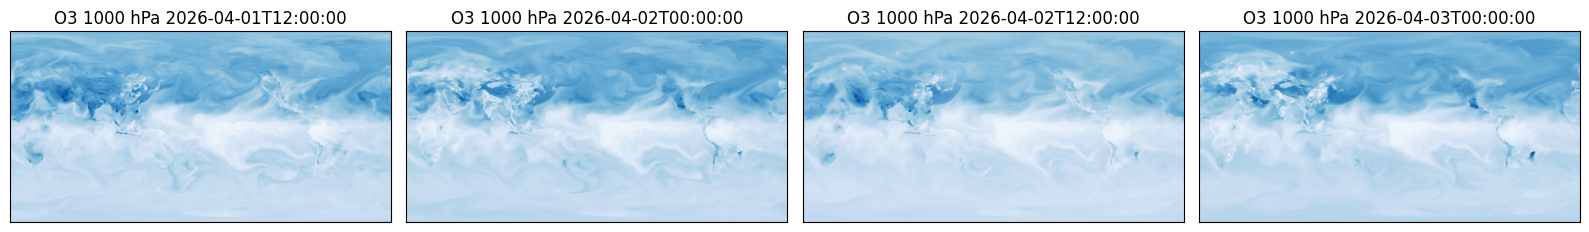

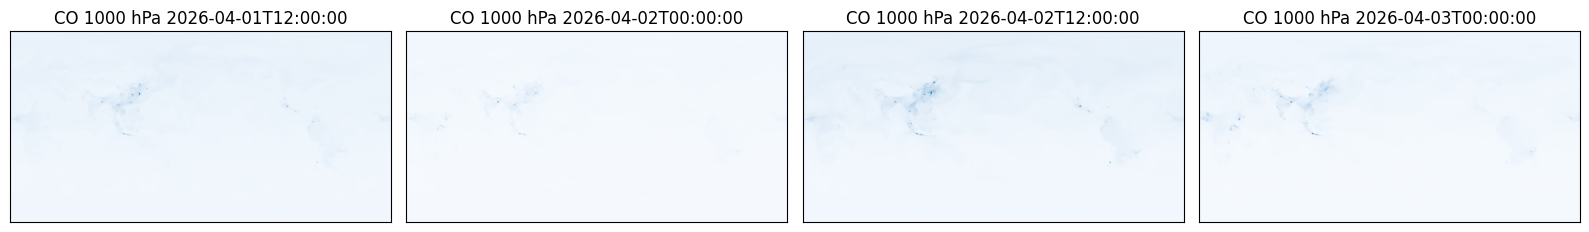

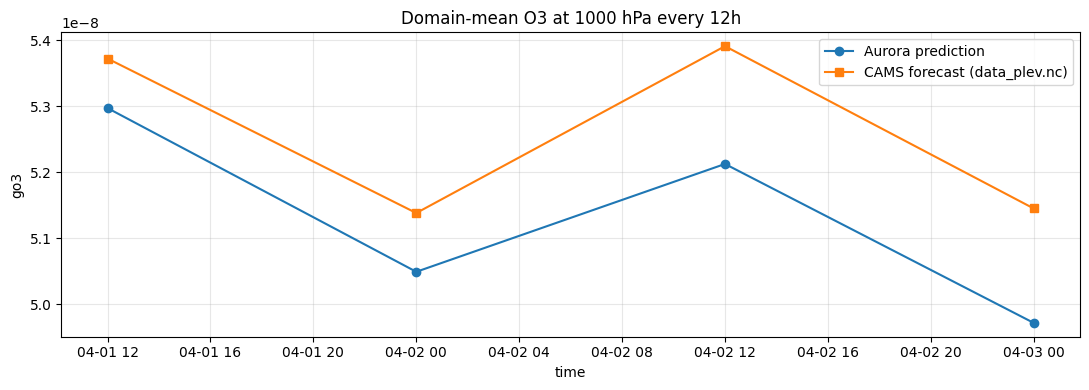

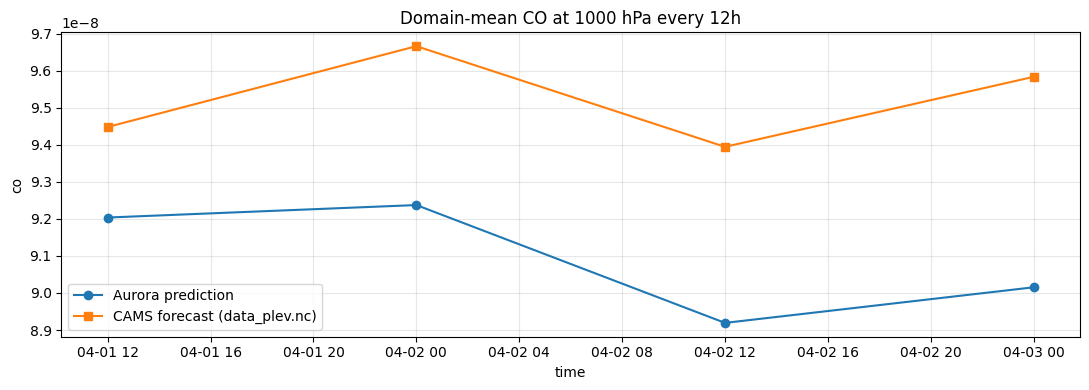

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

if not predictions:
    print("No predictions to plot or save. Set RUN_AURORA=True and run the rollout cell first.")
else:
    surface_var_map = {
        "2t": "t2m",
        "10u": "u10",
        "10v": "v10",
        "msl": "msl",
        "pm1": "pm1",
        "pm2p5": "pm2p5",
        "pm10": "pm10",
        "tcco": "tcco",
        "tc_no": "tc_no",
        "tcno2": "tcno2",
        "gtco3": "gtco3",
        "tcso2": "tcso2",
    }
    atmos_var_map = {
        "t": "t",
        "u": "u",
        "v": "v",
        "q": "q",
        "z": "z",
        "co": "co",
        "no": "no",
        "no2": "no2",
        "go3": "go3",
        "so2": "so2",
    }

    pred_time = np.array(
        [np.datetime64(pred.metadata.time[0], "s") for pred in predictions],
        dtype="datetime64[s]",
    )
    forecast_period = np.arange(
        AURORA_STEP_HOURS,
        AURORA_STEP_HOURS * (len(predictions) + 1),
        AURORA_STEP_HOURS,
        dtype=np.int32,
    ).astype("timedelta64[h]")

    # Use the prediction grid coordinates (Aurora can crop to patch-compatible size).
    pred_latitude = predictions[0].metadata.lat.cpu().numpy()
    pred_longitude = predictions[0].metadata.lon.cpu().numpy()

    ds_data_vars = {}
    for aurora_name, cams_name in surface_var_map.items():
        ds_data_vars[cams_name] = (
            ("time", "latitude", "longitude"),
            np.stack([pred.surf_vars[aurora_name][0, 0].cpu().numpy() for pred in predictions], axis=0),
        )

    for aurora_name, cams_name in atmos_var_map.items():
        ds_data_vars[cams_name] = (
            ("time", "pressure_level", "latitude", "longitude"),
            np.stack([pred.atmos_vars[aurora_name][0, 0].cpu().numpy() for pred in predictions], axis=0),
        )

    prediction_ds = xr.Dataset(
        data_vars=ds_data_vars,
        coords={
            "time": pred_time,
            "valid_time": ("time", pred_time),
            "forecast_period": ("time", forecast_period),
            "pressure_level": atmos_vars_ds.pressure_level.values,
            "latitude": pred_latitude,
            "longitude": pred_longitude,
            "forecast_reference_time": np.datetime64(
                INIT_DATETIME_UTC.replace(tzinfo=None), "s"
            ),
        },
        attrs={
            "source": "Aurora air pollution rollout",
            "init_datetime_utc": INIT_DATETIME_UTC.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "aurora_step_hours": AURORA_STEP_HOURS,
            "aurora_num_steps": len(predictions),
        },
    )

    for cams_name in surface_var_map.values():
        if cams_name in surf_vars_ds and hasattr(surf_vars_ds[cams_name], "attrs"):
            prediction_ds[cams_name].attrs = dict(surf_vars_ds[cams_name].attrs)
    for cams_name in atmos_var_map.values():
        if cams_name in atmos_vars_ds and hasattr(atmos_vars_ds[cams_name], "attrs"):
            prediction_ds[cams_name].attrs = dict(atmos_vars_ds[cams_name].attrs)

    if SAVE_PREDICTIONS_NETCDF:
        if predictions_output_path.exists() and not OVERWRITE_PREDICTIONS_NETCDF:
            print(
                f"Prediction NetCDF already exists and overwrite is disabled: {predictions_output_path}"
            )
        else:
            prediction_ds.to_netcdf(predictions_output_path)
            print(f"Saved Aurora predictions to {predictions_output_path}")

    # Maps for O3 and CO at 1000 hPa for every prediction step.
    level_values = prediction_ds.pressure_level.values.astype(int)
    if 1000 in set(level_values.tolist()):
        level_idx = int(np.where(level_values == 1000)[0][0])
        level_label = 1000
    else:
        level_idx = int(np.argmin(np.abs(level_values - 1000)))
        level_label = int(level_values[level_idx])
        print(f"1000 hPa level not found; using nearest level {level_label} hPa.")

    num_plots = len(predictions)
    ncols = 4
    nrows = (num_plots + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axs = np.atleast_1d(axs).ravel()
    for i, ax in enumerate(axs):
        if i >= num_plots:
            ax.axis("off")
            continue
        da = prediction_ds["go3"].isel(time=i, pressure_level=level_idx)
        ax.imshow(da.values, cmap="Blues")
        ax.set_title(f"O3 {level_label} hPa {prediction_ds.time.values[i]}")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()

    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axs = np.atleast_1d(axs).ravel()
    for i, ax in enumerate(axs):
        if i >= num_plots:
            ax.axis("off")
            continue
        da = prediction_ds["co"].isel(time=i, pressure_level=level_idx)
        ax.imshow(da.values, cmap="Blues")
        ax.set_title(f"CO {level_label} hPa {prediction_ds.time.values[i]}")
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()

    # Compare Aurora vs CAMS forecast (data_plev.nc) for O3 and CO at 1000 hPa.
    def _assign_time_from_forecast(ds):
        if "valid_time" in ds:
            vt = ds["valid_time"].values
            if getattr(vt, "ndim", 1) > 1:
                vt = vt.reshape(-1)
            vt = vt.astype("datetime64[s]")
            if "forecast_period" in ds.dims:
                ds = ds.assign_coords(time=("forecast_period", vt))
                ds = ds.swap_dims({"forecast_period": "time"})
            elif "time" in ds.dims:
                ds = ds.assign_coords(time=vt)
            return ds

        if "forecast_period" in ds.dims:
            fp = ds["forecast_period"].values.astype("timedelta64[h]")
            t0 = np.datetime64(INIT_DATETIME_UTC.replace(tzinfo=None), "s")
            ds = ds.assign_coords(time=("forecast_period", t0 + fp))
            ds = ds.swap_dims({"forecast_period": "time"})
            return ds

        return None

    if DO_DOWNLOAD_CAMS_FORECAST and forecast_atmos_path.exists():
        forecast_plev_ds = xr.open_dataset(forecast_atmos_path, engine="netcdf4", decode_timedelta=True)
        forecast_plev_ds = _assign_time_from_forecast(forecast_plev_ds)

        if forecast_plev_ds is None or "time" not in forecast_plev_ds.dims:
            print(f"Could not infer forecast time axis from {forecast_atmos_path}")
        else:
            if "pressure_level" in forecast_plev_ds.coords:
                if 1000 in set(forecast_plev_ds.pressure_level.values.astype(int).tolist()):
                    forecast_plev_1000 = forecast_plev_ds.sel(pressure_level=1000)
                else:
                    nearest_fcst_level = int(
                        forecast_plev_ds.pressure_level.values[
                            np.argmin(np.abs(forecast_plev_ds.pressure_level.values.astype(int) - 1000))
                        ]
                    )
                    print(
                        f"1000 hPa not found in forecast file; using nearest level {nearest_fcst_level} hPa."
                    )
                    forecast_plev_1000 = forecast_plev_ds.sel(pressure_level=nearest_fcst_level)
            else:
                print("No pressure_level coordinate in forecast atmospheric file.")
                forecast_plev_1000 = None

            if forecast_plev_1000 is not None:
                fp_hours = (
                    (forecast_plev_1000.time.values.astype("datetime64[s]") - np.datetime64(INIT_DATETIME_UTC.replace(tzinfo=None), "s"))
                    / np.timedelta64(1, "h")
                ).astype(int)
                cadence_mask = fp_hours % AURORA_STEP_HOURS == 0
                forecast_plev_1000 = forecast_plev_1000.isel(time=np.where(cadence_mask)[0])

                pred_1000 = prediction_ds.sel(pressure_level=level_label)
                for pred_var, fcst_var, label in [("go3", "go3", "O3"), ("co", "co", "CO")]:
                    if fcst_var not in forecast_plev_1000 or pred_var not in pred_1000:
                        print(f"Skipping comparison for {label}: variable missing.")
                        continue

                    pred_mean = pred_1000[pred_var].mean(dim=("latitude", "longitude"))
                    fcst_mean = forecast_plev_1000[fcst_var].mean(dim=("latitude", "longitude"))

                    common_times = np.intersect1d(
                        pred_mean.time.values.astype("datetime64[s]"),
                        fcst_mean.time.values.astype("datetime64[s]"),
                    )
                    if common_times.size == 0:
                        print(f"No overlapping timestamps for {label} {level_label} hPa comparison.")
                        continue

                    pred_common = pred_mean.sel(time=common_times)
                    fcst_common = fcst_mean.sel(time=common_times)

                    plt.figure(figsize=(11, 4))
                    plt.plot(pred_common.time.values, pred_common.values, marker="o", label="Aurora prediction")
                    plt.plot(fcst_common.time.values, fcst_common.values, marker="s", label="CAMS forecast (data_plev.nc)")
                    plt.title(f"Domain-mean {label} at {level_label} hPa every {AURORA_STEP_HOURS}h")
                    plt.xlabel("time")
                    plt.ylabel(pred_var)
                    plt.grid(True, alpha=0.3)
                    plt.legend()
                    plt.tight_layout()
    else:
        print(
            "Skipping O3/CO forecast comparison plot. "
            "Set DO_DOWNLOAD_CAMS_FORECAST=True and ensure forecast atmospheric file exists."
        )
